In [2]:
%load_ext autoreload
%autoreload 2

import re
import numpy as np
import pandas as pd
import scipy.sparse
from statsmodels.stats.multitest import multipletests
import scanpy as sc
import seaborn as sns   
from scipy import stats
import statsmodels.formula.api as smf



import derepression_functions

In [3]:
SAMPLE_VARIABLE  = "donor_id"
AGE              = "age_of_death"
ZONE_COL         = "zone"
LIBRARY_SIZE_COL = "total_counts"
CONDITION        = "condition"
HEALTHY_CONDITION    = "healthy"
DISEASED_CONDITION    = "diseased"
ZONE_COL = "zone"

COVARIATE_COLS = ["sex", "PC1", "PC2", "PC3", "PC4", "PC5"] # in addtion to mean log umi and squared version



# Load Bican

In [ ]:
BICAN_PATH = "/home/gdallagl/myworkdir/XDP/data/BICAN/STR_D1_Matrix/d1_cleaner_v3_raw_dv_wm_labeled.h5ad"

bican = sc.read_h5ad(BICAN_PATH)

print(bican.X[:200, :200].toarray().sum(axis=1))

# bican.X = bican.layers["counts"].astype("int32", copy=False)

# Rename columns to a consistent naming convention
bican.obs = bican.obs.rename(columns={
    "merge_step_6" : ZONE_COL,
    "donor_id"     : SAMPLE_VARIABLE,
    "age"          : AGE,
    "n_counts"     : LIBRARY_SIZE_COL,
    "imputed_sex"  : "sex",
})
bican.obs[CONDITION] = HEALTHY_CONDITION

# gene are gene_symbols

print(bican)
print(f"\nDonors : {bican.obs[SAMPLE_VARIABLE].nunique()}")
print(f"Zones  : {sorted(bican.obs[ZONE_COL].unique())}")
print(f"Age range: {bican.obs[AGE].min():.0f}–{bican.obs[AGE].max():.0f}")

[ 869. 1220. 1391. 1573.  850.  497. 1197. 1929. 1083. 1105. 1068. 1222.
 1109. 1095. 1025. 1248.  452.  976. 1488. 1528. 1488.  984. 1392. 1222.
 1307. 1512. 1272. 1072.  899. 1129.  997. 1089. 1327. 1256.  880. 1297.
 1248.  818. 1184. 1287. 1496. 1256. 1430. 1002. 1053. 1180. 1340.  980.
 1271. 1358. 1150. 1280. 1121. 1026.  940. 1312. 1253. 1621.  655.  959.
 1665. 1022. 1131.  946. 1376.  889.  482. 1193. 1320. 1300. 1404.  870.
  935. 1529.  710. 1467.  986. 1451. 1202.  384. 1038. 1594.  972. 1689.
 1149. 1622.  798.  929. 1730. 1200.  854.  570.  810. 1024. 1069.  609.
 1161. 1142. 1125. 1058.  870.  879. 1170.  592. 1031.  683.  704. 1361.
 1331. 1122. 1323. 1578. 1180. 1226. 1194. 1214. 1149. 1047. 1266.  770.
  913. 1165.  955.  405. 1380. 1125. 1172. 1459. 1446. 1159. 1649. 1127.
 1014. 1237. 1049. 1289. 1219. 1009.  866. 1200. 1547. 1127. 1420. 1061.
 1240. 1022.  766.  816. 1195. 1162. 1102. 1138.  778.  965. 1215. 1260.
 1017. 1157. 1276. 1155. 1648.  710. 1232. 1659.  7

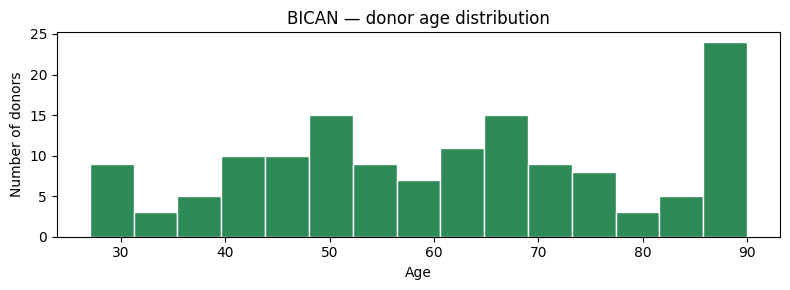

In [5]:
import matplotlib.pyplot as plt


# Quick overview of donor ages across the full dataset
donor_meta = bican.obs.drop_duplicates(SAMPLE_VARIABLE)[[SAMPLE_VARIABLE, AGE]].copy()
donor_meta[AGE] = donor_meta[AGE].astype(float)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(donor_meta[AGE], bins=15, color="seagreen", edgecolor="white")
ax.set_xlabel("Age")
ax.set_ylabel("Number of donors")
ax.set_title("BICAN — donor age distribution")
plt.tight_layout()
plt.show()

# Only healthy analsysis

In [33]:
THR_DR = [0.1]#,  0.020.05, 0.1]
MIN_CELL_PER_SAMPLE = 30
N_PERM = 10_000
FDR_ALPHA = 0.05
SEED = 42
DEREPRESSION_SCORE_METHOD = ["scanpy_score"]#, "ucell"]

ZONES = sorted(bican.obs[ZONE_COL].unique().tolist())

In [ ]:
all_summaries  = {}
all_gene_lists = {}
all_results    = {}       
all_models     = {}

for score_method in DEREPRESSION_SCORE_METHOD:
    for thr in THR_DR:
        print(f"\n=== Score method: {score_method} | DR threshold: {thr} ===")

        for zone in ZONES:
            print(f"\n  Processing zone: {zone}")
            key = (score_method, thr, zone)

            adata_zone = bican[bican.obs[ZONE_COL] == zone].copy()

            gene_list, results_df, donor_meta = derepression_functions.find_depressed_genes(
                adata_zone,
                donor_col            = SAMPLE_VARIABLE,
                age_col              = AGE,
                tot_UMI_per_cell_col = LIBRARY_SIZE_COL,
                threshold            = thr,              # ← was THR_DR (the list), now thr
                min_cells            = MIN_CELL_PER_SAMPLE,
                n_perm               = N_PERM,
                fdr_alpha            = FDR_ALPHA,
                seed                 = SEED,
            )

            summary = derepression_functions.compute_scores_and_cov(
                adata_zone, gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
                umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, cov_cols=None,
                score_method=score_method,               # ← was hardcoded "scanpy_score"
                percentile=90,
            )
            summary["zone"]         = zone
            summary["score_method"] = score_method
            summary["thr"]          = thr

            formula = "score_S ~ age_scaled + median_log_umi_scaled"
            model   = smf.ols(formula, data=summary).fit()

            all_summaries[key]  = summary
            all_gene_lists[key] = gene_list
            all_results[key]    = results_df
            all_models[key]     = model

# ── Combine all summaries ─────────────────────────────────────────────────────
combined = pd.concat(all_summaries.values(), ignore_index=True)


=== Score method: scanpy_score | DR threshold: 0.1 ===

  Processing zone: 1
  Donors kept: 114  (dropped 27 with < 30 cells)
  Downsampling to 32 cells per donor


/home/gdallagl/myworkdir/XDP/script/NucSeq/de-repression/derepression_functions.py:394: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_sub = adata[adata.obs.groupby(donor_col).sample(n=min_n, random_state=seed).index].copy()


  After downsampling: donor_id
MD6366        32
MD6417        32
MD6424        32
MD6433        32
MD6434        32
              ..
UMBEB23041    32
UMBEB23048    32
UMBEB23073    32
UMBEB23076    32
UMBEB24009    32
Name: count, Length: 114, dtype: int64 cells, 38100 genes, 114 donors


/home/gdallagl/myworkdir/XDP/script/NucSeq/de-repression/derepression_functions.py:409: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_meta = adata.obs.groupby(donor_col).agg(


  Young (≤47): 29  |  Old (≥75): 30
  Candidates: 21775
  Running permutation test (10,000 perms)...
  Significant (padj < 0.05): 360  →  360 genes


In [ ]:
# from itertools import product
# from joblib import Parallel, delayed

# # Pre-extract zones — much smaller than full bican
# zone_adatas = {zone: bican[bican.obs[ZONE_COL] == zone].copy() for zone in ZONES}
# del bican  # free the big object

# def process_one(adata_zone, score_method, thr, zone):  # adata passed as arg, not closure
#     key = (score_method, thr, zone)

#     gene_list, results_df, donor_meta = derepression_functions.find_depressed_genes(
#         adata_zone,
#         donor_col            = SAMPLE_VARIABLE,
#         age_col              = AGE,
#         tot_UMI_per_cell_col = LIBRARY_SIZE_COL,
#         threshold            = thr,
#         min_cells            = MIN_CELL_PER_SAMPLE,
#         n_perm               = N_PERM,
#         fdr_alpha            = FDR_ALPHA,
#         seed                 = SEED,
#     )

#     summary = derepression_functions.compute_scores_and_cov(
#         adata_zone, gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
#         umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, cov_cols=None,
#         score_method=score_method, percentile=90,
#     )
#     summary["zone"]         = zone
#     summary["score_method"] = score_method
#     summary["thr"]          = thr

#     formula = "score_S ~ age_scaled + median_log_umi_scaled"
#     model   = smf.ols(formula, data=summary).fit()

#     return key, summary, gene_list, model


# all_combos = list(product(DEREPRESSION_SCORE_METHOD, THR_DR, ZONES))

# results = Parallel(n_jobs=2, verbose=10)(  # keep n_jobs low
#     delayed(process_one)(zone_adatas[zone], sm, thr, zone)
#     for sm, thr, zone in all_combos
# )

# all_summaries  = {key: summary   for key, summary, _, _      in results}
# all_gene_lists = {key: gene_list for key, _, gene_list, _    in results}
# all_models     = {key: model     for key, _, _, model         in results}

# combined = pd.concat(all_summaries.values(), ignore_index=True)


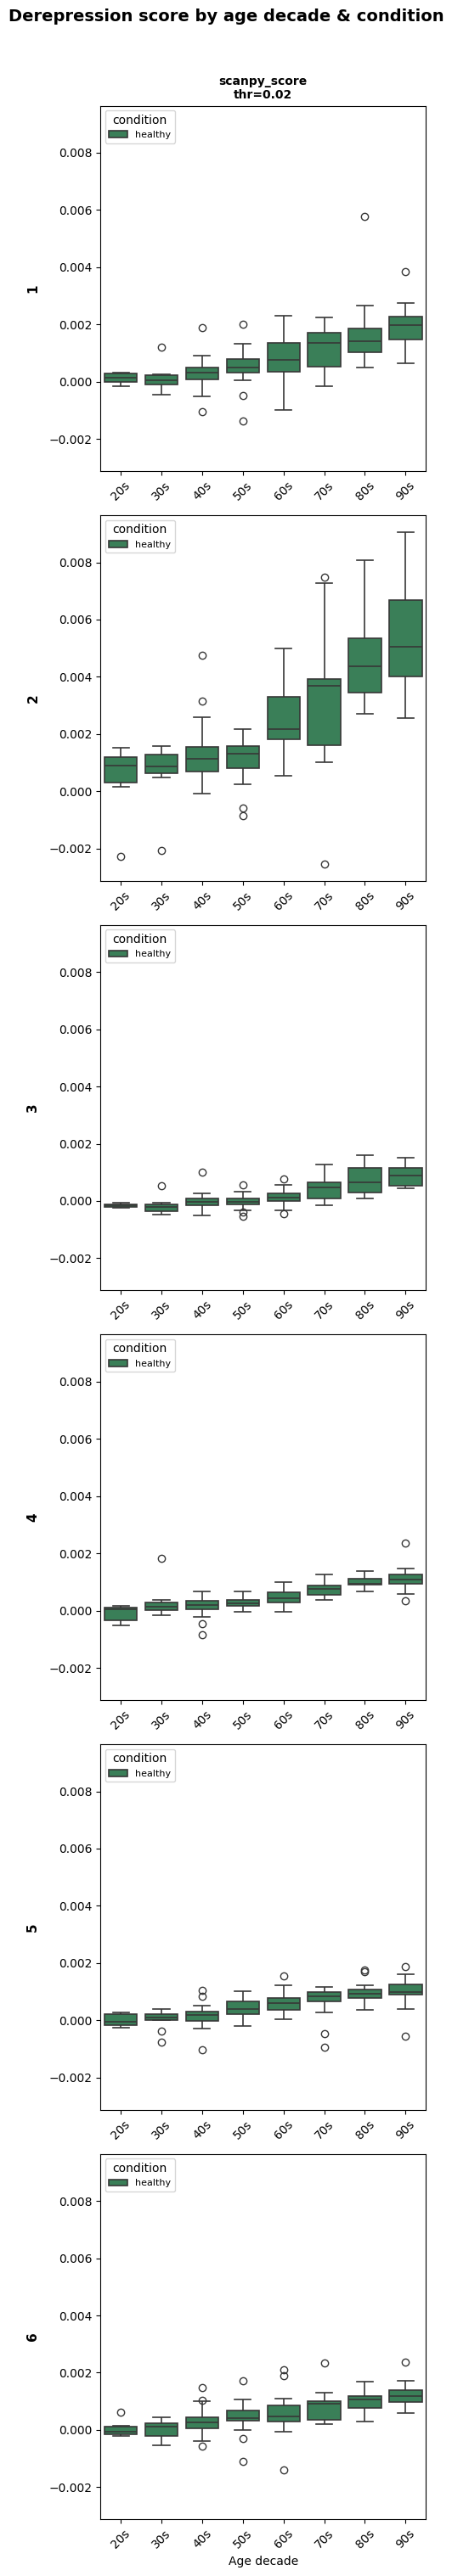

In [ ]:
import math
import itertools

def add_decade(df):
    df = df.copy()
    df["age_decade"] = (df["age"] // 10 * 10).astype(int).astype(str) + "s"
    return df

combos   = list(itertools.product(DEREPRESSION_SCORE_METHOD, THR_DR))
n_rows   = len(ZONES)
n_cols   = len(combos)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), sharey=True)

if n_rows == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

for row_idx, zone in enumerate(ZONES):
    for col_idx, (score_method, thr) in enumerate(combos):
        ax  = axes[row_idx, col_idx]
        key = (score_method, thr, zone)

        if key not in all_summaries:
            ax.set_visible(False)
            continue

        df_zone      = add_decade(all_summaries[key])
        decade_order = sorted(
            df_zone["age_decade"].unique(),
            key=lambda x: int(x[:-1])
        )

        sns.boxplot(
            data      = df_zone,
            x         = "age_decade",
            y         = "score_S",
            hue       = CONDITION,
            order     = decade_order,
            palette   = {"healthy": "seagreen", "diseased": "lightcoral"},
            linewidth = 1.2,
            ax        = ax,
        )

        # Column header (combo) only on first row
        if row_idx == 0:
            ax.set_title(f"{score_method}\nthr={thr}", fontsize=10, fontweight="bold")

        # Row label (zone) only on first column
        if col_idx == 0:
            ax.set_ylabel(zone, fontsize=11, fontweight="bold", labelpad=8)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Age decade" if row_idx == n_rows - 1 else "")
        ax.tick_params(axis="x", labelrotation=45)

        # Legend only on last column
        if col_idx == n_cols - 1:
            ax.legend(title=CONDITION, fontsize=8, loc="upper left")
        else:
            ax.get_legend().remove() if ax.get_legend() else None

fig.suptitle(
    "Derepression score by age decade & condition",
    y=1.01, fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [ ]:
# # ── 3. One row per zone – individual boxplots grouped by decade, colored by decade ──
# import math
# import matplotlib.patches as mpatches
# import matplotlib.colors as mcolors

# def add_decade(df):
#     df = df.copy()
#     df["age_decade"] = (df["age"] // 10 * 10).astype(int).astype(str) + "s"
#     return df

# INNER_GAP   = 0.4    # gap between ages within a decade
# DECADE_GAP  = 1.2    # extra gap between decades
# COND_OFFSET = 0.15   # left/right nudge for healthy vs diseased
# HATCHES     = {"healthy": "", "diseased": "///"}

# def build_x_positions(age_order):
#     positions  = {}
#     x          = 0
#     prev_decade = None
#     for age in age_order:
#         dec = age // 10 * 10
#         if prev_decade is not None and dec != prev_decade:
#             x += DECADE_GAP
#         positions[age] = x
#         x += INNER_GAP
#         prev_decade = dec
#     return positions

# def make_decade_palette(decades, cmap_name="tab10"):
#     cmap = plt.get_cmap(cmap_name)
#     return {d: mcolors.to_hex(cmap(i / max(len(decades) - 1, 1)))
#             for i, d in enumerate(sorted(decades, key=lambda x: int(x[:-1])))}

# n_zones = len(ZONES)
# fig, axes = plt.subplots(n_zones, 1, figsize=(20, 4 * n_zones), sharey=True)
# axes_flat = np.atleast_1d(axes)

# for idx, zone in enumerate(ZONES):
#     ax      = axes_flat[idx]
#     df_zone = add_decade(all_summaries[zone])

#     age_order    = sorted(df_zone["age"].unique())
#     conditions   = sorted(df_zone[CONDITION].unique())
#     x_pos        = build_x_positions(age_order)
#     decades      = sorted(df_zone["age_decade"].unique(), key=lambda x: int(x[:-1]))
#     dec_palette  = make_decade_palette(decades)
#     offsets      = {c: (i - (len(conditions) - 1) / 2) * COND_OFFSET
#                     for i, c in enumerate(conditions)}

#     for cond in conditions:
#             df_cond = df_zone[df_zone[CONDITION] == cond]
#             for age in age_order:
#                 df_box = df_cond[df_cond["age"] == age]["score_S"].dropna()
#                 if df_box.empty:
#                     continue
#                 decade_color = dec_palette[f"{(age // 10) * 10}s"]
#                 ax.boxplot(
#                     df_box,
#                     positions    = [x_pos[age] + offsets[cond]],
#                     widths       = COND_OFFSET * 1.5,
#                     patch_artist = True,
#                     boxprops     = dict(facecolor=decade_color, alpha=0.8,
#                                         hatch=HATCHES[cond]),
#                     medianprops  = dict(color="black", linewidth=1.5),
#                     whiskerprops = dict(linewidth=1.0),
#                     capprops     = dict(linewidth=1.0),
#                     flierprops   = dict(marker="o", markersize=3, alpha=0.5,
#                                         markerfacecolor=decade_color,
#                                         markeredgecolor=decade_color),  # ← added
#                     manage_ticks = False,
#                 )

#     # ── NEW: tell matplotlib where the data actually lives ──
#     all_x = [x_pos[a] + offsets[c] for a in age_order for c in conditions]
#     ax.set_xlim(min(all_x) - COND_OFFSET * 3, max(all_x) + COND_OFFSET * 3)

#     # x-axis ticks at the mean position of each decade's ages
#     decade_ticks = {}
#     for age in age_order:
#         dec = f"{(age // 10) * 10}s"
#         decade_ticks.setdefault(dec, []).append(x_pos[age])
#     ax.set_xticks([np.mean(v) for v in decade_ticks.values()])
#     ax.set_xticklabels(list(decade_ticks.keys()))
#     ax.set_title(zone)
#     ax.set_xlabel("Age decade")
#     ax.set_ylabel("score_S")

#     # Legend: decade colors + condition hatches
#     decade_handles = [mpatches.Patch(facecolor=dec_palette[d], label=d)
#                       for d in decades]
#     cond_handles   = [mpatches.Patch(facecolor="white", edgecolor="black",
#                                      hatch=HATCHES[c], label=c)
#                       for c in conditions]
#     ax.legend(handles=decade_handles + cond_handles,
#               title="decade  /  condition", fontsize=8, loc="upper left")

# fig.suptitle("Derepression score by age & condition – all zones", y=1.02)
# plt.tight_layout()
# plt.show()

# Check for PRC2 enrichment

In [30]:
prc2_genes = {
    "prc2_enzymatic_components":              ["EZH1", "EZH2"],
    "prc2_nonenzymatic_components":           ["SUZ12", "JARID2"],
    "h3k27me3_demethylases":                  ["KDM6B", "KDM6A"],   # mouse Jmjd3 / Utx
    "death_promoting_silenced_by_prc2":       ["PMAIP1", "BID", "CDKN2A", "CDKN2B", "CCND1", "WT1", "IGFBP3", "TP73"],  # mouse Trp73 → TP73
    "msn_identity_genes_downregulated":       ["DRD1", "DRD2", "ADORA2A", "PDE10A", "ARPP21", "RGS9", "FOXP1", "RXRG", "BCL11B", "GPR6", "KCND2", "PPP1R1B"],  # mouse Drd1a → DRD1
    "purkinje_cell_genes_lost":               ["CALB1", "PCP2", "PVALB", "RORA", "FXN", "EBF3", "LHX1", "LHX5"],
    "hox":           ["HOXA3", "HOXA4", "HOXA5", "HOXA7", "HOXA9", "HOXA10", "HOXB2", "HOXB3", "HOXB5", "HOXB6", "HOXB7", "HOXB8", "HOXB13", "HOXC4", "HOXC5", "HOXC8", "HOXC10", "HOXD3", "HOXD8", "HOXD9", "HOXD10", "HOXD11", "HOXD13"],
    "t_box":         ["EOMES", "TBX2", "TBX3", "TBX20"],
    "pou":           ["POU4F1", "POU4F2"],
    "gata":          ["GATA2", "GATA3", "GATA4", "GATA6"],
    "cardiac":       ["NKX2-5", "HAND2", "TWIST1"],
    "hematopoietic": ["TAL1", "RUNX3"],
    "pituitary":     ["PITX1", "PITX2"],
    "neuronal":      ["NEUROD1", "NEUROD2", "NEUROG2"],
    "lim":           ["LHX1", "LHX5", "LHX9"],
    "hypothalamic":  ["SIM1", "SIM2"],
    "forkhead":      ["FOXA1", "FOXD1", "FOXD2", "FOXL2"],
    "other":         ["ZIC2", "EN1", "ONECUT1", "BARX1", "SFMBT2", "BHLHE22", "DLX4", "EBF3", "FOXF1", "GRHL1", "IRX2", "IRX3", "IRX5", "LBX1", "LMX1B", "NKX3-1", "NKX6-1", "PAX1", "PAX3", "PAX6", "SHOX2", "SIX1", "SIX2", "SIX6", "TLX1", "CBX4", "DMRT2", "DMRT3", "DMRTA2"],
}

adata_genes = set(bican.var_names)

for family, genes in prc2_genes.items():
    found    = [g for g in genes if g in adata_genes]
    missing  = [g for g in genes if g not in adata_genes]
    print(f"{family:40s}  {len(found)}/{len(genes)}  found: {found}")

prc2_enzymatic_components                 2/2  found: ['EZH1', 'EZH2']
prc2_nonenzymatic_components              2/2  found: ['SUZ12', 'JARID2']
h3k27me3_demethylases                     2/2  found: ['KDM6B', 'KDM6A']
death_promoting_silenced_by_prc2          8/8  found: ['PMAIP1', 'BID', 'CDKN2A', 'CDKN2B', 'CCND1', 'WT1', 'IGFBP3', 'TP73']
msn_identity_genes_downregulated          12/12  found: ['DRD1', 'DRD2', 'ADORA2A', 'PDE10A', 'ARPP21', 'RGS9', 'FOXP1', 'RXRG', 'BCL11B', 'GPR6', 'KCND2', 'PPP1R1B']
purkinje_cell_genes_lost                  8/8  found: ['CALB1', 'PCP2', 'PVALB', 'RORA', 'FXN', 'EBF3', 'LHX1', 'LHX5']
hox                                       23/23  found: ['HOXA3', 'HOXA4', 'HOXA5', 'HOXA7', 'HOXA9', 'HOXA10', 'HOXB2', 'HOXB3', 'HOXB5', 'HOXB6', 'HOXB7', 'HOXB8', 'HOXB13', 'HOXC4', 'HOXC5', 'HOXC8', 'HOXC10', 'HOXD3', 'HOXD8', 'HOXD9', 'HOXD10', 'HOXD11', 'HOXD13']
t_box                                     4/4  found: ['EOMES', 'TBX2', 'TBX3', 'TBX20']
pou       

In [26]:
list_results = []

for score_method in DEREPRESSION_SCORE_METHOD:
    for thr in THR_DR:
        for zone in ZONES:
            for gene_family in prc2_genes:

                key            = (score_method, thr, zone)
                polycomb_genes = prc2_genes[gene_family]
                results_df     = all_results[key].copy()

                result = derepression_functions.polycomb_enrichment_cmh(
                    results_df,
                    polycomb_genes,
                    fdr_alpha = 0.05,
                    n_bins    = 20,
                )

                # add metadata so every row is self-contained
                result["score_method"] = score_method
                result["thr"]          = thr
                result["zone"]         = zone
                result["gene_family"]  = gene_family

                list_results.append(result)

# ── Build tidy DataFrame ───────────────────────────────────────────────────
INDEX_COLS  = ["score_method", "thr", "zone", "gene_family"]
RESULT_COLS = ["odds_ratio", "pval", "overlap", "n_sig",
               "n_pc_cands", "n_candidates", "n_strata"]

df_polycomb_enrichment = (
    pd.DataFrame(list_results)
      [INDEX_COLS + RESULT_COLS]          # fix column order
      .sort_values(INDEX_COLS)            # sort rows logically
      .reset_index(drop=True)
)

df_polycomb_enrichment

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/stats/contingency_tables.py:1077: RuntimeWarning: invalid value encountered in scalar divide
  odds_ratio = np.sum(self._ad / self._n) / np.sum(self._bc / self._n)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/stats/contingency_tables.py:1058: RuntimeWarning: invalid value encountered in scalar divide
  statistic /= denom


,score_method,thr,zone,gene_family,odds_ratio,pval,overlap,n_sig,n_pc_cands,n_candidates,n_strata
0,scanpy_score,0.02,1,cardiac,0.0,0.538120,0,102,3,14782,14
1,scanpy_score,0.02,1,death_promoting_silenced_by_prc2,0.0,0.584640,0,102,4,14782,14
2,scanpy_score,0.02,1,forkhead,0.0,0.588603,0,102,4,14782,14
3,scanpy_score,0.02,1,gata,0.0,0.548515,0,102,4,14782,14
4,scanpy_score,0.02,1,h3k27me3_demethylases,NaN,NaN,0,102,0,14782,14
...,...,...,...,...,...,...,...,...,...,...,...
103,scanpy_score,0.02,6,pou,NaN,NaN,0,146,2,14322,12
104,scanpy_score,0.02,6,prc2_enzymatic_components,NaN,NaN,0,146,0,14322,12
105,scanpy_score,0.02,6,prc2_nonenzymatic_components,NaN,NaN,0,146,0,14322,12
106,scanpy_score,0.02,6,purkinje_cell_genes_lost,0.0,0.596486,0,146,3,14322,12


In [32]:
df_polycomb_enrichment[df_polycomb_enrichment.pval < 0.05]

df_polycomb_enrichment[df_polycomb_enrichment.overlap > 0]
df_polycomb_enrichment[df_polycomb_enrichment.n_pc_cands > 0]

,score_method,thr,zone,gene_family,odds_ratio,pval,overlap,n_sig,n_pc_cands,n_candidates,n_strata
0,scanpy_score,0.02,1,cardiac,0.0,0.538120,0,102,3,14782,14
1,scanpy_score,0.02,1,death_promoting_silenced_by_prc2,0.0,0.584640,0,102,4,14782,14
2,scanpy_score,0.02,1,forkhead,0.0,0.588603,0,102,4,14782,14
3,scanpy_score,0.02,1,gata,0.0,0.548515,0,102,4,14782,14
5,scanpy_score,0.02,1,hematopoietic,0.0,0.530478,0,102,2,14782,14
...,...,...,...,...,...,...,...,...,...,...,...
101,scanpy_score,0.02,6,other,0.0,0.734192,0,146,21,14322,12
102,scanpy_score,0.02,6,pituitary,0.0,0.551626,0,146,2,14322,12
103,scanpy_score,0.02,6,pou,NaN,NaN,0,146,2,14322,12
106,scanpy_score,0.02,6,purkinje_cell_genes_lost,0.0,0.596486,0,146,3,14322,12


# Load NucSeq

In [ ]:
ADATA_PATH = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"
nucseq = sc.read_h5ad(ADATA_PATH, backed="r")

# Use gene symbols as var_names (rather than Ensembl IDs)
nucseq.var.index = nucseq.var["gene_symbol"]

# Normalise cell-type labels (replace spaces with underscores)
nucseq.obs["ct_for_deg"] = nucseq.obs["ct_for_deg"].str.replace(" ", "_")

# Select only D1 Matrix
nucseq = nucseq[nucseq.obs["ct_for_deg"] == "D1_Matrix"].to_memory().copy()

print(nucseq)

AnnData object with n_obs × n_vars = 0 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_onset',

In [ ]:
import seaborn as sns

df_donors_bican = bican_zone.obs.drop_duplicates(subset='donor_id').copy()
df_donors       = adata_zone.obs.drop_duplicates(subset='donor_id').copy()

df_donors_bican['source'] = 'BICAN (healthy)'
df_donors['source'] = df_donors[CONTRAST_VARIABLE].map({
    CONTRAST_BASELINE: 'NucSeq Control',
    CONTRAST_STIM:     'NucSeq XDP',
})

df_merged = pd.concat([
    df_donors_bican[[AGE, 'source']],
    df_donors[[AGE, 'source']],
])
df_merged[AGE] = df_merged[AGE].astype(float)
df_merged['age_decade'] = (df_merged[AGE] // 10 * 10).astype(int).astype(str) + 's'

# Keep only decades present in the data, sorted
decade_order = sorted(df_merged['age_decade'].unique())

palette = {
    'BICAN (healthy)': 'seagreen',
    'NucSeq XDP':      'tomato',
    'NucSeq Control':  'steelblue',
}

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(
    data=df_merged, x='age_decade', hue='source',
    order=decade_order, palette=palette, ax=ax,
)
ax.set_xlabel('Age decade')
ax.set_ylabel('Number of donors')
sns.despine()
plt.tight_layout()
plt.show()


# XDP derepression

In [ ]:
for zone, gene_list in all_gene_lists:
    print(f"\n\nProcessing zone: {zone}")

    bican_zone = bican[bican.obs[ZONE_COL] == zone].copy()
    nucseq_zone = nucseq[nucseq.obs[ZONE_COL] == zone].copy()



    # Remove donors with fewer than N cells (too noisy for detection-rate estimates)
    MIN_CELLS_PER_DONOR = 10

    def filter_low_cell_donors(adata, sample_col, min_cells):
        counts    = adata.obs[sample_col].value_counts()
        keep      = counts[counts >= min_cells].index
        return adata[adata.obs[sample_col].isin(keep)].copy()

    nucseq_zone = filter_low_cell_donors(nucseq_zone, SAMPLE_VARIABLE, MIN_CELLS_PER_DONOR)
    bican_zone = filter_low_cell_donors(bican_zone, SAMPLE_VARIABLE, MIN_CELLS_PER_DONOR)

    print(f"After filtering — NucSeq: {nucseq_zone.obs[SAMPLE_VARIABLE].nunique()} donors")
    print(f"After filtering — BICAN:  {bican_zone.obs[SAMPLE_VARIABLE].nunique()} donors")




    # Subset samples in H (both dataset) to only have the same age range of D?





    # calculte scores INDEPEDENLTY
    SCORE_TYPE = "scanpy_score"
    summary_nucseq = derepression_functions.compute_scores_and_cov(
        nucseq_zone, gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
        umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, cov_cols=None,
        score_method=SCORE_TYPE, percentile=90,
    )
    summary_nucseq["dataset"] = "nucseq"
    summary_nucseq["zone"] = "zone"
    summary_bican = derepression_functions.compute_scores_and_cov(
        bican_zone, gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
        umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, cov_cols=None,
        score_method=SCORE_TYPE, percentile=90,
    )

    
    # Merge summaries
    df_merged = pd.concat([summary_nucseq, summary_bican])


    print(df_merged["age"].describe())
    # If std < 8–10 years, drop the interaction term

    # Run test
    formula = "score_S ~ age_scaled + C(condition) + age_scaled:condition + C(dataset) + median_umi_scaled" # pct90_derepressed ~ age_scaled * is_xdp + median_umi_scaled
    cov_col = None
    if cov_col:
        formula += " + " + " + ".join(cov_col)
    model = smf.ols(formula, data=df_merged).fit()





In [ ]:
MIN_CELLS_PER_DONOR = 10
SCORE_TYPE          = "scanpy_score"

def filter_low_cell_donors(adata, sample_col, min_cells):
    keep = adata.obs[sample_col].value_counts()
    keep = keep[keep >= min_cells].index
    return adata[adata.obs[sample_col].isin(keep)].copy()

zone_models = {}

for zone, gene_list in all_gene_lists.items():   # .items() — was missing
    print(f"\n── Zone {zone} ──────────────────────────────────────────────")

    # ── 1. Subset to zone, drop low-cell donors ───────────────────────────
    bican_zone  = bican [bican.obs [ZONE_COL] == zone].copy()
    nucseq_zone = nucseq[nucseq.obs[ZONE_COL] == zone].copy()

    bican_zone  = filter_low_cell_donors(bican_zone,  SAMPLE_VARIABLE, MIN_CELLS_PER_DONOR)
    nucseq_zone = filter_low_cell_donors(nucseq_zone, SAMPLE_VARIABLE, MIN_CELLS_PER_DONOR)

    print(f"  BICAN : {bican_zone.obs [SAMPLE_VARIABLE].nunique()} donors")
    print(f"  NucSeq: {nucseq_zone.obs[SAMPLE_VARIABLE].nunique()} donors")

    # ── 2. Clip BICAN to XDP age range (avoid extrapolation) ─────────────
    xdp_ages       = nucseq_zone.obs.drop_duplicates(SAMPLE_VARIABLE)[AGE].astype(float)
    age_lo, age_hi = xdp_ages.min(), xdp_ages.max()
    bican_zone     = bican_zone[bican_zone.obs[AGE].astype(float).between(age_lo, age_hi)].copy()
    print(f"  BICAN clipped to [{age_lo:.0f}–{age_hi:.0f}] → {bican_zone.obs[SAMPLE_VARIABLE].nunique()} donors remain")

    # ── 3. Score independently per dataset ───────────────────────────────
    # Normalisation and scanpy_score background computed within each dataset
    summary_bican  = derepression_functions.compute_scores_and_cov(
        bican_zone,  gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
        umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, score_method=SCORE_TYPE, percentile=90,
    )
    summary_nucseq = derepression_functions.compute_scores_and_cov(
        nucseq_zone, gene_set=gene_list, donor_col=SAMPLE_VARIABLE, age_col=AGE,
        umi_col=LIBRARY_SIZE_COL, condition_col=CONDITION, score_method=SCORE_TYPE, percentile=90,
    )
    summary_bican ["dataset"] = "bican"
    summary_nucseq["dataset"] = "nucseq"

    # ── 4. Merge and re-scale on the combined df ──────────────────────────
    # Scores were scaled independently → must redo scaling on the joint data
    df = pd.concat([summary_bican, summary_nucseq], ignore_index=True)
    df["zone"]              = zone
    df["age_scaled"]        = (df["age"]        - df["age"].mean())        / df["age"].std()
    df["median_umi_scaled"] = (df["median_umi"] - df["median_umi"].mean()) / df["median_umi"].std()

    # ── 5. OLS ────────────────────────────────────────────────────────────
    # Interaction needs enough age spread in XDP to estimate a slope within D
    if xdp_ages.std() > 8:
        formula = "score_S ~ age_scaled * C(condition) + C(dataset) + median_umi_scaled"
    else:
        formula = "score_S ~ age_scaled + C(condition) + C(dataset) + median_umi_scaled"
        print(f"  ⚠  XDP age std = {xdp_ages.std():.1f} yrs — interaction term dropped")

    model = smf.ols(formula, data=df).fit()
    print(model.summary())

    zone_models[zone] = {"model": model, "df": df}



── Zone 1 ──────────────────────────────────────────────


NameError: name 'nucseq' is not defined

## Compute scores

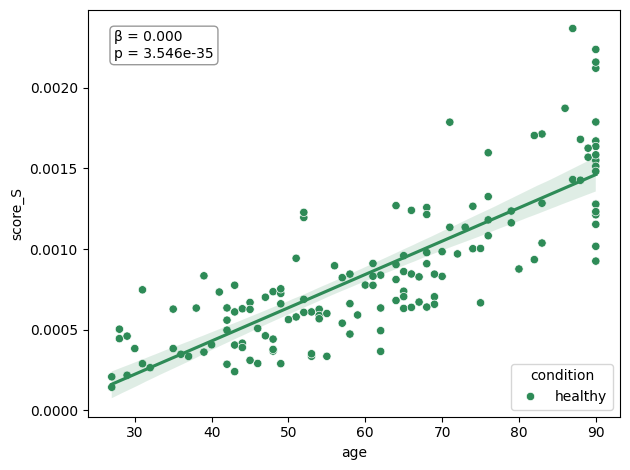

In [ ]:
from scipy import stats

# fit
slope, intercept, r_value, p_value, std_err = stats.linregress(summary["age"], summary["score_S"])

# plot
fig, ax = plt.subplots()
sns.scatterplot(data=summary, x="age", y="score_S", color="seagreen", edgecolor="white", ax=ax, hue=CONDITION, palette={"healthy": "seagreen", "diseased": "lightcoral"})
sns.regplot(data=summary, x="age", y="score_S", scatter=False, color="seagreen", ax=ax)

ax.annotate(
    f"β = {slope:.3f}\np = {p_value:.3e}",
    xy=(0.05, 0.95), xycoords="axes fraction",
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

plt.tight_layout()
plt.show()

# test score

In [ ]:
model_design = "age_only"  # options: "age_only", "condition", "interaction"
covariate_cols = None  # or specify extra covariate columns if needed

if model_design == "age_only":
    formula = "score_S ~ age_scaled + median_umi_scaled"
elif model_design == "condition":
    formula = "score_S ~ age_scaled + condition + median_umi_scaled"
elif model_design == "interaction":
    formula = "score_S ~ age_scaled + condition + age_scaled:condition + median_umi_scaled"

if covariate_cols:
        formula += " + " + " + ".join(covariate_cols)

model = smf.ols(formula, data=summary).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                score_S   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     163.4
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           2.49e-37
Time:                        19:51:59   Log-Likelihood:                 980.55
No. Observations:                 143   AIC:                            -1955.
Df Residuals:                     140   BIC:                            -1946.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.0009   2.15e-0

In [ ]:
bican

AnnData object with n_obs × n_vars = 206571 × 38100
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age_of_death', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate_spn_en', 'scpred_caudate_spn_en_max_prob', 'scpred_caudate_spn_mp', 'scpred_caudate_spn_mp_max_prob', 

In [ ]:
bican.obs['total_counts']

v12_10X-GEMX-3P_CaH_CTGCAAATCGTGCCTC         122792
v12_10X-GEMX-3P_CaH_CCGTCTATCAGTACGC         170012
v12_10X-GEMX-3P_CaH_CAAGGATAGAATCATC         171900
v12_10X-GEMX-3P_CaH_ACACTGATCGCGTAAC         219100
v12_10X-GEMX-3P_CaH_GTGTTATAGGTTCAAT         127135
                                              ...  
v94_10X-GEMX-3P_NAC_rxn8_GGTAAATGTAGGTTAG    171912
v94_10X-GEMX-3P_NAC_rxn8_ACACAACCACATAGTA     65686
v94_10X-GEMX-3P_NAC_rxn8_TCCCCAGCATCCCTAA    142402
v94_10X-GEMX-3P_NAC_rxn8_TACGAACCATCCTTAG    147213
v94_10X-GEMX-3P_NAC_rxn8_CTGTGCCTCTGGATTG    147355
Name: total_counts, Length: 206571, dtype: int64